In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
from init_utils import sigmoid, relu, compute_loss, forward_propagation, backward_propagation
from init_utils import update_parameters, predict, load_dataset, plot_decision_boundary, predict_dec

plt.rcParams['figure.figsize'] = (7.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

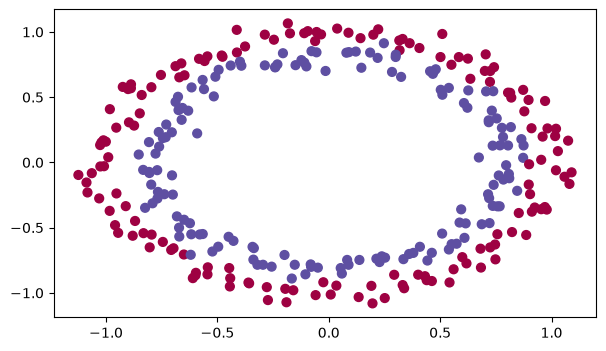

In [2]:
train_X, train_Y, test_X, test_Y = load_dataset()

In [5]:
def model(X, Y, learning_rate = 0.01, num_iterations = 15000,print_cost = True, initialization = 'he'):
    
    grads = {}
    costs = []
    m = X.shape[1]
    layers_dims = [X.shape[0], 10, 5, 1]
    
    if initialization == "zeros":
        parameters = initialize_parameters_zeros(layers_dims)
    elif initialization == "random":
        parameters = initialize_parameters_random(layers_dims)
    elif initialization == "he":
        parameters = initialize_parameters_he(layers_dims)

    for i in range( 0 , num_iterations):

        a3, cache = forward_propagation(X, parameters)

        cost = compute_loss(a3, Y)

        grads = backward_propagation(X, Y, cache)

        parameters = update_parameters(parameters, grads, learning_rate)

        if print_cost and i % 1000 == 0:
            print('cost after iteration {}: {}'.format(i,cost))
            costs.append(cost)


    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()
    
    return parameters
        

In [7]:
def initialize_parameters_zeros(layers_dims):
    L = len(layers_dims)
    parameters = {}
    for l in range(1, L):
        parameters['W' + str(l)] = np.zeros((layers_dims[l], layers_dims[l-1]))
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))

    return parameters

In [8]:
def initialize_parameters_random(layers_dims):
    L = len(layers_dims)
    parameters = {}
    
    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1]) * 10
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))

    return parameters   

In [9]:
def initialize_parameters_he(layers_dims):
    L = len(layers_dims)
    parameters = {}
    
    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1]) * np.sqrt(2 / layers_dims[l-1])
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))

    return parameters 

cost after iteration 0: 0.7368485967804638
cost after iteration 1000: 0.6771399580072878
cost after iteration 2000: 0.6700328157136244
cost after iteration 3000: 0.6560286195416574
cost after iteration 4000: 0.630671621972103
cost after iteration 5000: 0.5877874061480516
cost after iteration 6000: 0.5221668644447744
cost after iteration 7000: 0.44275843972471535
cost after iteration 8000: 0.3523693928802174
cost after iteration 9000: 0.2708942984309909
cost after iteration 10000: 0.20460829851880954
cost after iteration 11000: 0.1594693505371807
cost after iteration 12000: 0.12954661317605007
cost after iteration 13000: 0.10807825598020818
cost after iteration 14000: 0.09241594012258349


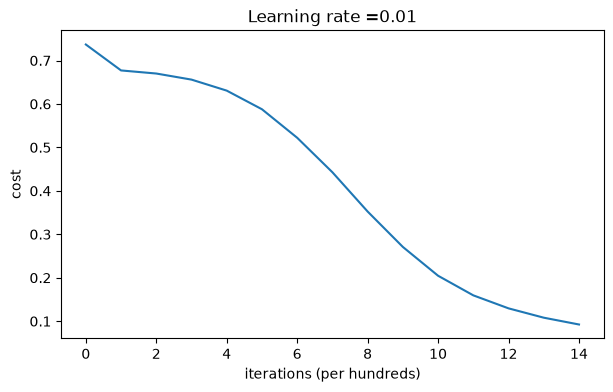

On the train set:


AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [10]:
parameters = model(train_X, train_Y, initialization = "he")
print ("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print ("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

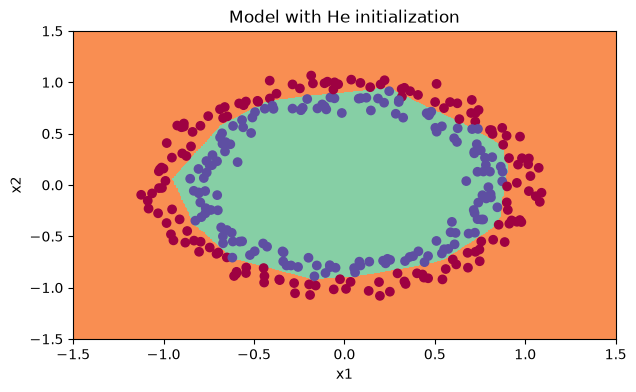

In [11]:

plt.title("Model with He initialization")
axes = plt.gca()
axes.set_xlim([-1.5,1.5])
axes.set_ylim([-1.5,1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)